# Lecture 13e: Logging a Hyperparameter Sweep as Parent/Child Runs

A `GridSearchCV` is really a **sweep** over many configurations: every `C` value, every
classifier setting, is its own little experiment.
MLflow can record that whole sweep as **one PARENT run** with **one CHILD run per configuration**,
so the UI shows the sweep as a tidy tree you can sort, filter, and compare.

**What this notebook covers**

- Structuring a sweep as a **parent run** (the sweep) plus **nested child runs** (each config).
- Logging a per-sweep diagnostic **figure** with `mlflow.log_figure` (a validation curve, plus a confusion matrix for the best config).
- Pulling the children back with `mlflow.search_runs(...)` filtered to the parent, then ranking them in a DataFrame.
- A **pointer** to Optuna for larger / continuous search spaces.

> **Optional / career-track.** The mandatory notebooks `lec_13c` and `lec_13d` already cover tracking, evaluation, and the registry.
> This one is extra depth for anyone heading toward an MLOps role.

Forward pointer: the mandatory `lec_13d_mlflow_evaluation_registry.ipynb` covers evaluation gates and the model registry; `lec_13f_mlflow_model_serving.ipynb` serves a registered model over REST.

## The tracking store (recap from lec_13c)

The executable cells below log **directly to a local SQLite file**, so the notebook runs headless.
To *browse* what you logged, start a server in a **separate terminal** pointed at the same file:

```bash
# one-time, in a separate terminal:
mlflow server --backend-store-uri sqlite:///mlflow.db \
              --default-artifact-root ./mlartifacts --host 127.0.0.1 --port 5000
# then open http://127.0.0.1:5000
# (a read-only viewer is enough here:  mlflow ui --backend-store-uri sqlite:///mlflow.db)
```

- **`mlflow ui`** = read-only viewer over an existing store.
- **`mlflow server`** = full server (UI + REST API + model serving).
- The store has **three layers**: backend store (params / metrics / tags -> our SQLite file),
  artifact store (models / plots / files -> a local folder), model registry (versioned named models).

Everything the cells below log to `mlflow.db` shows up in that UI once the server is running.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

import requests
import mlflow

RANDOM_STATE = 42

## 1. Data (the shared Lecture 13 contract)

Same heart-disease dataset and same column split as every Lecture 13 notebook.

In [2]:
# Heart-disease dataset (committed alongside this notebook). 630k rows -> sample for fast teaching.
df = (
    pd.read_csv("predict_heart_disease_train.csv")
    .drop(columns=["id"])
    .sample(n=1500, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Binary target: 1 = heart disease present, 0 = absent
y = (df["Heart Disease"] == "Presence").astype(int)
X = df.drop(columns=["Heart Disease"])

# Continuous numeric features -> scale; integer-coded categorical features -> one-hot encode
NUMERIC = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
CATEGORICAL = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
               "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((1125, 13), (375, 13))

## 2. One pipeline, swept over `C`

We reuse the standard preprocessing `ColumnTransformer` and chain it to a `LogisticRegression`.
The thing we will **sweep** is the regularisation strength `C`: smaller `C` = stronger regularisation.

A `Pipeline` matters here because cross-validation must re-fit the scaler/encoder on each training fold
only — that is what keeps the sweep **leakage-free**.

In [3]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# The sweep: a small grid of regularisation strengths.
C_VALUES = [0.01, 0.1, 1.0, 10.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Point MLflow at the sweep's store

Same two lines as `lec_13c`: a tracking URI (the SQLite file) and an experiment name.

In [4]:
# Prefer a running `mlflow server` so runs show up live in the web UI; if it is not
# running, fall back to the same SQLite file directly so the notebook still runs.
MLFLOW_UI = "http://127.0.0.1:5000"

def mlflow_server_running(uri=MLFLOW_UI, timeout=2):
    """True if an `mlflow server` answers on /health, else False."""
    try:
        return requests.get(f"{uri}/health", timeout=timeout).status_code == 200
    except requests.exceptions.RequestException:
        return False

if mlflow_server_running():
    mlflow.set_tracking_uri(MLFLOW_UI)
    print(f"MLflow server is UP at {MLFLOW_UI} -- runs appear live in the web UI.")
    print(f"Open {MLFLOW_UI} in your browser to watch this experiment fill up.")
else:
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    print("MLflow server is NOT running -- logging to the local SQLite store 'mlflow.db'.")
    print("To explore these runs in the UI, open a terminal in this folder and run:")
    print("    mlflow server --backend-store-uri sqlite:///mlflow.db \\")
    print("                  --default-artifact-root ./mlartifacts --port 5000")
    print("then open http://127.0.0.1:5000  (re-run this cell to switch to the server).")
mlflow.set_experiment("lecture13_sweeps")

2026/06/02 22:43:38 INFO mlflow.tracking.fluent: Experiment with name 'lecture13_sweeps' does not exist. Creating a new experiment.


MLflow server is UP at http://127.0.0.1:5000 -- runs appear live in the web UI.
Open http://127.0.0.1:5000 in your browser to watch this experiment fill up.


<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1780429418769, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1780429418769, lifecycle_stage='active', name='lecture13_sweeps', tags={}, trace_location=None, workspace='default'>

## 4. The sweep as PARENT + CHILD runs

The pattern is two nested `with` blocks:

- The **outer** `with mlflow.start_run(run_name="C_sweep")` opens the **parent** — it represents the whole sweep.
- Inside the loop, **`with mlflow.start_run(nested=True, ...)`** opens one **child per `C` value**.
  Each child logs its own param (`C`) and its own metric (mean CV accuracy).

In the UI the children appear indented under the parent, so you can expand the sweep and compare configs at a glance.
We collect the per-`C` scores into `sweep_rows` as we go, to plot a validation curve next.

In [5]:
sweep_rows = []  # (C, mean_cv_acc, std_cv_acc) for the validation curve

with mlflow.start_run(run_name="C_sweep") as parent:
    parent_run_id = parent.info.run_id
    mlflow.log_param("swept_param", "clf__C")
    mlflow.log_param("cv_folds", cv.get_n_splits())

    for c in C_VALUES:
        with mlflow.start_run(nested=True, run_name=f"C={c}"):
            pipe.set_params(clf__C=c)
            scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
            mean_acc, std_acc = scores.mean(), scores.std()

            mlflow.log_param("clf__C", c)
            mlflow.log_metric("cv_accuracy", mean_acc)
            mlflow.log_metric("cv_accuracy_std", std_acc)

            sweep_rows.append((c, mean_acc, std_acc))
            print(f"C={c:<6}  cv_accuracy = {mean_acc:.3f} +/- {std_acc:.3f}")

sweep_df = pd.DataFrame(sweep_rows, columns=["C", "cv_accuracy", "cv_accuracy_std"])
sweep_df

C=0.01    cv_accuracy = 0.878 +/- 0.012
🏃 View run C=0.01 at: http://127.0.0.1:5000/#/experiments/3/runs/a9148b119f284b678a42e20024cf9f30
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
C=0.1     cv_accuracy = 0.884 +/- 0.017
🏃 View run C=0.1 at: http://127.0.0.1:5000/#/experiments/3/runs/10550f7d2ef64ba28c90867a63096c7b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
C=1.0     cv_accuracy = 0.879 +/- 0.018
🏃 View run C=1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/c72baaebdba04841b4ff60a4921d3cdf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
C=10.0    cv_accuracy = 0.877 +/- 0.019
🏃 View run C=10.0 at: http://127.0.0.1:5000/#/experiments/3/runs/7d552f0bf62c4e0c84ffbb7dc4c2126c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
🏃 View run C_sweep at: http://127.0.0.1:5000/#/experiments/3/runs/0a1d98b2281442aa8d4f287615943329
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


,C,cv_accuracy,cv_accuracy_std
0,0.01,0.878222,0.011792
1,0.10,0.883556,0.017190
2,1.00,0.879111,0.017866
3,10.00,0.877333,0.018561


## 5. Log a validation-curve figure with `mlflow.log_figure`

`mlflow.log_figure(fig, "name.png")` saves a matplotlib figure straight into the **artifact store** of the
active run — no need to write a file to disk yourself.

Here we re-open the **parent** run and attach a **validation curve**: mean CV accuracy versus `C`
(log scale), with a shaded +/- 1 std band. One picture of the whole sweep.

🏃 View run C_sweep at: http://127.0.0.1:5000/#/experiments/3/runs/0a1d98b2281442aa8d4f287615943329
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


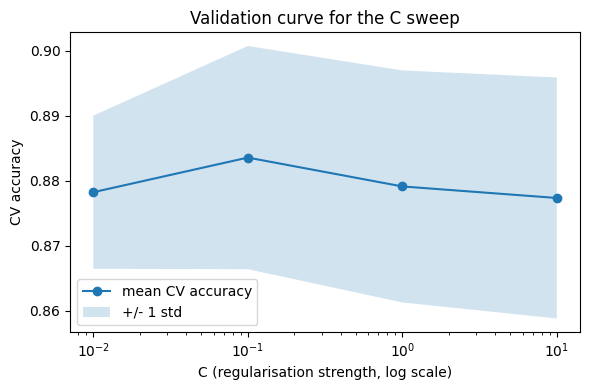

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep_df["C"], sweep_df["cv_accuracy"], marker="o", label="mean CV accuracy")
ax.fill_between(
    sweep_df["C"],
    sweep_df["cv_accuracy"] - sweep_df["cv_accuracy_std"],
    sweep_df["cv_accuracy"] + sweep_df["cv_accuracy_std"],
    alpha=0.2, label="+/- 1 std",
)
ax.set_xscale("log")
ax.set_xlabel("C (regularisation strength, log scale)")
ax.set_ylabel("CV accuracy")
ax.set_title("Validation curve for the C sweep")
ax.legend()
fig.tight_layout()

# Re-open the parent run and attach the figure to ITS artifacts.
with mlflow.start_run(run_id=parent_run_id):
    mlflow.log_figure(fig, "validation_curve.png")
plt.show()

## 6. A confusion matrix for the best config

We pick the `C` with the highest mean CV accuracy, refit the pipeline on the full training set,
and log its **confusion matrix** (on the held-out test set) as a second figure under the parent.

🏃 View run C_sweep at: http://127.0.0.1:5000/#/experiments/3/runs/0a1d98b2281442aa8d4f287615943329
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


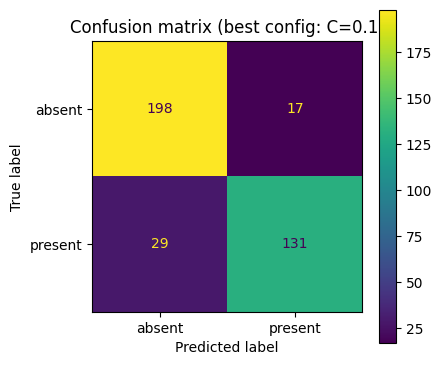

In [7]:
best_c = sweep_df.loc[sweep_df["cv_accuracy"].idxmax(), "C"]

pipe.set_params(clf__C=best_c)
pipe.fit(X_train, y_train)

fig_cm, ax_cm = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(
    pipe, X_test, y_test, display_labels=["absent", "present"], ax=ax_cm
)
ax_cm.set_title(f"Confusion matrix (best config: C={best_c})")
fig_cm.tight_layout()

with mlflow.start_run(run_id=parent_run_id):
    mlflow.log_param("best_C", float(best_c))
    mlflow.log_figure(fig_cm, "confusion_matrix_best.png")
plt.show()

## 7. Pull the children back with `mlflow.search_runs`

Every child run carries a tag `mlflow.parentRunId` pointing at its parent.
Filtering on that tag returns exactly this sweep's children — no matter how many other runs share the experiment.

## See the sweep in the MLflow UI

Open **http://127.0.0.1:5000**, click the **`lecture13_sweeps`** experiment, and expand the **parent run**: each `C` value is a **nested child run** you can sort and compare. Open a child run's **Artifacts** tab to see the **validation-curve** and **confusion-matrix** figures logged with `mlflow.log_figure`.

In [8]:
children = mlflow.search_runs(
    experiment_names=["lecture13_sweeps"],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
)

# Keep just the columns that matter and rank by CV accuracy.
ranked = (
    children[["params.clf__C", "metrics.cv_accuracy", "metrics.cv_accuracy_std"]]
    .rename(columns={
        "params.clf__C": "C",
        "metrics.cv_accuracy": "cv_accuracy",
        "metrics.cv_accuracy_std": "cv_accuracy_std",
    })
    .astype({"cv_accuracy": float, "cv_accuracy_std": float})
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)
ranked

,C,cv_accuracy,cv_accuracy_std
0,0.1,0.883556,0.017190
1,1.0,0.879111,0.017866
2,0.01,0.878222,0.011792
3,10.0,0.877333,0.018561


In [9]:
best_row = ranked.iloc[0]
print(f"Best child: C={best_row['C']}  ->  cv_accuracy = {best_row['cv_accuracy']:.3f}")

Best child: C=0.1  ->  cv_accuracy = 0.884


## 8. Where Optuna slots in (pointer)

Our grid had four `C` values. Real sweeps often have **many continuous knobs** (learning rates, depths,
regularisation), where an exhaustive grid explodes.
For those, a **Bayesian optimiser like [Optuna](https://optuna.org/)** replaces the grid: it proposes the
*next* configuration to try based on what it has learned so far, instead of trying everything blindly.

The structure you just built **maps onto Optuna 1:1** — the study is the **parent** run, and each Optuna
**trial** is a **child** run. So the parent/child logging pattern carries over unchanged; only the
config-generating loop is swapped for `study.optimize(...)`.
See the [Optuna + MLflow integration docs](https://optuna.org/#dashboard) for the `MLflowCallback`.

## Notes

- A sweep = **one parent run** + **one nested child run per config**; `nested=True` is the whole trick.
- `mlflow.log_figure(fig, "name.png")` attaches a plot to the active run's artifacts — no manual file I/O.
- Re-open any run later with `mlflow.start_run(run_id=...)` to add more params, metrics, or figures.
- `mlflow.search_runs(filter_string="tags.mlflow.parentRunId = '<id>'")` retrieves a sweep's children for ranking.
- For large / continuous search spaces, reach for **Optuna**; the parent/child layout stays the same.